In [121]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error

In [122]:
# Data
x_train = pd.read_csv("../data/x_train_final.csv")
y_train = pd.read_csv("../data/y_train_final.csv")
x_test = pd.read_csv("../data/x_test_final.csv")

In [123]:
x_train

,Unnamed: 0.1,Unnamed: 0,train,gare,date,arret,p2q0,p3q0,p4q0,p0q2,p0q3,p0q4
0,0,0,VBXNMF,KYF,2023-04-03,8,0.0,0.0,1.0,-3.0,-1.0,-2.0
1,1,1,VBXNMF,JLR,2023-04-03,9,0.0,0.0,0.0,1.0,0.0,1.0
2,2,2,VBXNMF,EOH,2023-04-03,10,-1.0,0.0,0.0,-1.0,0.0,0.0
3,3,3,VBXNMF,VXY,2023-04-03,11,-1.0,-1.0,0.0,2.0,-2.0,0.0
4,4,4,VBXNMF,OCB,2023-04-03,12,-1.0,-1.0,-1.0,-1.0,3.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...
667259,667259,667259,BFNJJK,DGG,2023-11-10,22,0.0,-1.0,-6.0,-1.0,0.0,-2.0
667260,667260,667260,BFNJJK,KDN,2023-11-10,23,0.0,0.0,-1.0,1.0,0.0,0.0
667261,667261,667261,BFNJJK,TVD,2023-11-10,24,1.0,0.0,0.0,-1.0,-3.0,-1.0
667262,667262,667262,BFNJJK,TXP,2023-11-10,26,2.0,2.0,1.0,0.0,0.0,1.0


In [124]:
y_train

,Unnamed: 0,p0q0
0,0,-1.0
1,1,-1.0
2,2,-1.0
3,3,1.0
4,4,3.0
...,...,...
667259,667259,1.0
667260,667260,2.0
667261,667261,2.0
667262,667262,1.0


## Feature Engineering

In [137]:
def fit_features(train_df: pd.DataFrame) -> dict:
    df = train_df.copy()
    df["date"] = pd.to_datetime(df["date"])

    # Outliers
    df.loc[df["p0q3"] <= -500, "p0q3"] = (df["p0q2"] + df["p0q4"]) / 2
    df.loc[df["p0q4"] <= -500, "p0q4"] = (df["p0q2"] + df["p0q3"]) / 2

    cols_retard = ["p2q0", "p3q0", "p4q0", "p0q2", "p0q3", "p0q4"]

    mappings = {
        "freq_gare": df["gare"].value_counts(normalize=True),
        "retard_moyen_gare": df.groupby("gare")[cols_retard].mean().mean(axis=1),
    }
    return mappings


def transform_features(df: pd.DataFrame, mappings: dict) -> pd.DataFrame:
    df = df.copy()

    # Date
    df["date"] = pd.to_datetime(df["date"])
    df["month"] = df["date"].dt.month
    df["day_of_week"] = df["date"].dt.dayofweek

    # Encodage cyclique
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
    df["day_of_week_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 5)
    df["day_of_week_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 5)

    # Frequency encoding gare (depuis le train set)
    df["encoded_gare"] = df["gare"].map(mappings["freq_gare"]).fillna(0)

    # Outliers
    df.loc[df["p0q3"] <= -500, "p0q3"] = (df["p0q2"] + df["p0q4"]) / 2
    df.loc[df["p0q4"] <= -500, "p0q4"] = (df["p0q2"] + df["p0q3"]) / 2

    # Features agrégées
    df["somme_retard_prev_trains"] = df["p2q0"] + df["p3q0"] + df["p4q0"]
    df["somme_retard_prev_gares"] = df["p0q2"] + df["p0q3"] + df["p0q4"]

    # Retard moyen par gare (depuis le train set)
    df["retard_moyen_gare"] = df["gare"].map(mappings["retard_moyen_gare"]).fillna(0)

    # Nombre d'arrêts par train/date
    df["nb_arrets"] = df.groupby(["train", "date"])["arret"].transform("count")

    # Drop colonnes inutiles
    cols_to_drop = ["Unnamed: 0.1", "Unnamed: 0", "date", "day_of_week", "month", "gare", "train"]
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

    return df

In [138]:
# Fit sur train, transform sur train et test
mappings = fit_features(x_train)
x_train_fe = transform_features(x_train, mappings)
x_test_fe = transform_features(x_test, mappings)

In [139]:
x_train_fe

,arret,p2q0,p3q0,p4q0,p0q2,p0q3,p0q4,month_sin,month_cos,day_of_week_sin,day_of_week_cos,encoded_gare,somme_retard_prev_trains,somme_retard_prev_gares,retard_moyen_gare,nb_arrets
0,8,0.0,0.0,1.0,-3.0,-1.0,-2.0,0.866025,-0.500000,0.000000,1.000000,0.044566,1.0,-6.0,-0.566903,5
1,9,0.0,0.0,0.0,1.0,0.0,1.0,0.866025,-0.500000,0.000000,1.000000,0.047422,0.0,2.0,-0.093991,5
2,10,-1.0,0.0,0.0,-1.0,0.0,0.0,0.866025,-0.500000,0.000000,1.000000,0.039021,-1.0,-1.0,-0.183342,5
3,11,-1.0,-1.0,0.0,2.0,-2.0,0.0,0.866025,-0.500000,0.000000,1.000000,0.041726,-2.0,0.0,-0.436343,5
4,12,-1.0,-1.0,-1.0,-1.0,3.0,2.0,0.866025,-0.500000,0.000000,1.000000,0.043806,-3.0,4.0,-0.316142,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
667259,22,0.0,-1.0,-6.0,-1.0,0.0,-2.0,-0.500000,0.866025,-0.951057,0.309017,0.011484,-7.0,-3.0,-0.066706,19
667260,23,0.0,0.0,-1.0,1.0,0.0,0.0,-0.500000,0.866025,-0.951057,0.309017,0.011627,-1.0,1.0,0.336298,19
667261,24,1.0,0.0,0.0,-1.0,-3.0,-1.0,-0.500000,0.866025,-0.951057,0.309017,0.013987,1.0,-5.0,0.394514,19
667262,26,2.0,2.0,1.0,0.0,0.0,1.0,-0.500000,0.866025,-0.951057,0.309017,0.001278,5.0,1.0,0.395858,19


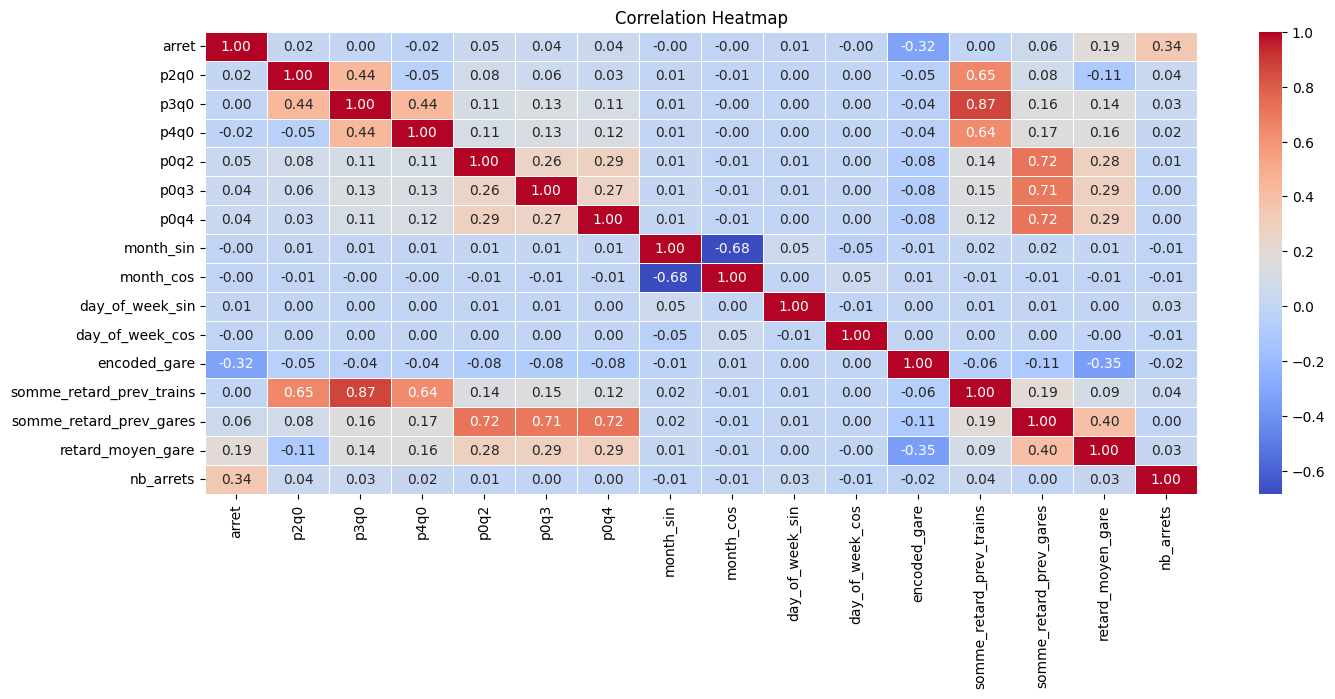

In [140]:
matrix = x_train_fe.corr()
plt.figure(figsize=(16,6))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [141]:
x_test_fe

,arret,p2q0,p3q0,p4q0,p0q2,p0q3,p0q4,month_sin,month_cos,day_of_week_sin,day_of_week_cos,encoded_gare,somme_retard_prev_trains,somme_retard_prev_gares,retard_moyen_gare,nb_arrets
0,12,0.0,0.0,-2.0,-4.0,-2.0,-4.0,-5.000000e-01,0.866025,0.000000,1.000000,0.041726,-2.0,-10.0,-0.436343,1
1,12,0.0,0.0,-1.0,1.0,-1.0,0.0,-5.000000e-01,0.866025,0.000000,1.000000,0.041726,-1.0,0.0,-0.436343,1
2,12,0.0,1.0,-1.0,1.0,-1.0,1.0,-5.000000e-01,0.866025,0.000000,1.000000,0.041726,0.0,1.0,-0.436343,1
3,12,0.0,0.0,-1.0,-1.0,0.0,-1.0,-5.000000e-01,0.866025,0.000000,1.000000,0.041726,-1.0,-2.0,-0.436343,1
4,12,1.0,-2.0,0.0,0.0,0.0,0.0,-5.000000e-01,0.866025,0.000000,1.000000,0.018413,-1.0,0.0,-0.195711,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20652,24,-1.0,-1.0,1.0,0.0,1.0,0.0,-2.449294e-16,1.000000,-0.951057,0.309017,0.025739,-1.0,1.0,-0.015342,2
20653,12,0.0,0.0,0.0,0.0,0.0,0.0,-2.449294e-16,1.000000,-0.951057,0.309017,0.012695,0.0,0.0,-0.179888,4
20654,18,1.0,-2.0,0.0,-1.0,-1.0,-2.0,-2.449294e-16,1.000000,-0.951057,0.309017,0.032145,-1.0,-4.0,-0.805236,4
20655,24,-2.0,-2.0,1.0,0.0,0.0,1.0,-2.449294e-16,1.000000,-0.951057,0.309017,0.025739,-3.0,1.0,-0.015342,4


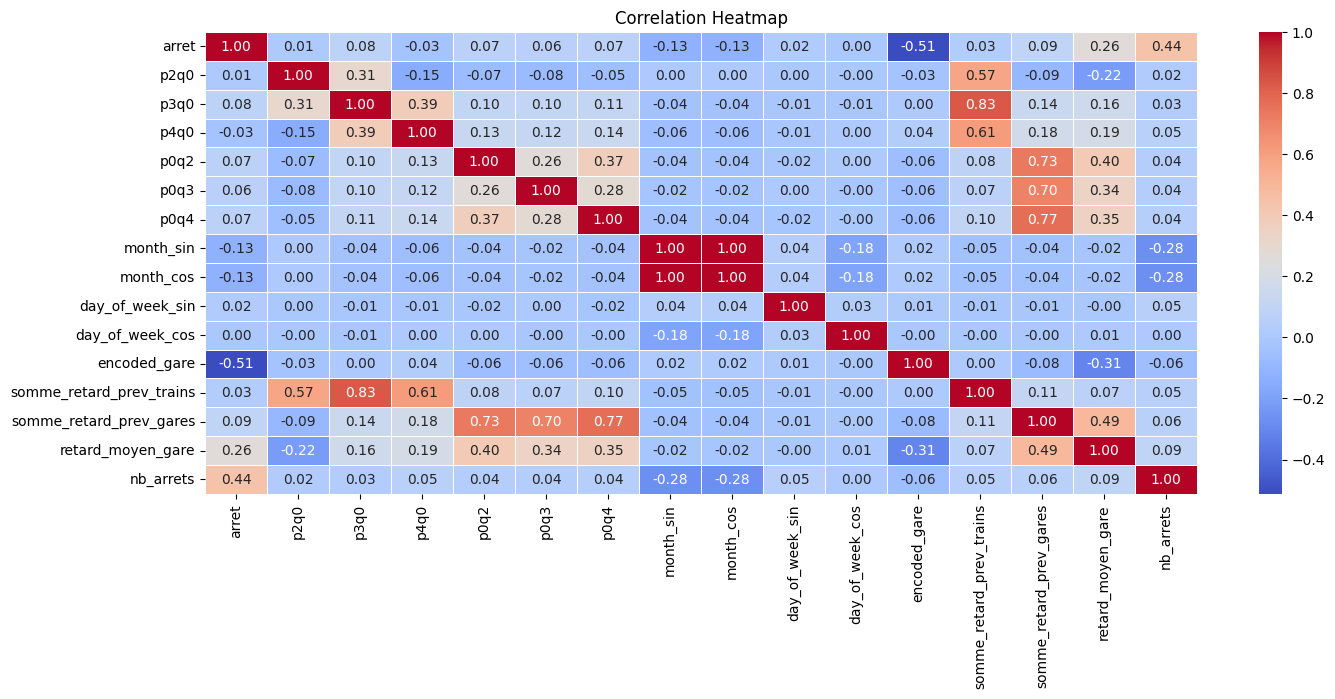

In [143]:
matrix = x_test_fe.corr()
plt.figure(figsize=(16,6))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

## Modeles

In [ ]:
import xgboost as xgb

SEED = 42

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

oof_preds = np.zeros(len(x_train_fe))
test_preds = np.zeros(len(x_test_fe))
fold_scores = []

X = x_train_fe.values
X_test = x_test_fe.values
y =  y_train.drop(columns=["Unnamed: 0"])["p0q0"].values 

# Paramètres XGBoost
xgb_params = {
    "n_estimators": 5000,
    "learning_rate": 0.01,
    "max_depth": 8,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "tree_method": "hist",
    "random_state": SEED
}

print(f"Entraînement en {kf.n_splits} folds...")
print("─" * 60)

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y), 1):
    X_tr, X_val = X[train_idx], X[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]

    model = xgb.XGBRegressor(**xgb_params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    val_pred = model.predict(X_val)
    oof_preds[val_idx] = val_pred
    test_preds += model.predict(X_test) / kf.n_splits

    score = mean_absolute_error(y_val, val_pred)
    fold_scores.append(score)
    print(f"  Fold {fold} | MAE = {score:.4f}")

print("─" * 60)
oof_score = mean_absolute_error(y, oof_preds)
print(f"  OOF global        | MAE = {oof_score:.4f}")
print(f"  Moyenne des folds | MAE = {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}")

Entraînement en 5 folds...
────────────────────────────────────────────────────────────
  Fold 1 | MAE = 0.7104
  Fold 2 | MAE = 0.7212
  Fold 3 | MAE = 0.7179
  Fold 4 | MAE = 0.7113
  Fold 5 | MAE = 0.7153
────────────────────────────────────────────────────────────
  OOF global        | MAE = 0.7152
  Moyenne des folds | MAE = 0.7152 ± 0.0040


## Optimisation Optuna

In [ ]:
import optuna

SEED = 42

X = x_train_fe.values

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
y =  y_train.drop(columns=["Unnamed: 0"])["p0q0"].values 

def objective(trial):

    params = {
        "n_estimators": 5000,
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.05),
        "max_depth": trial.suggest_int("max_depth", 4, 10),
        "subsample": trial.suggest_float("subsample", 0.6, 0.9),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 0.9),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 2),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 2),
        "reg_lambda": trial.suggest_float("reg_lambda", 1, 10),
        "tree_method": "gpu_hist",
        "random_state": SEED
    }

    oof_preds = np.zeros(len(X))

    for train_idx, val_idx in kf.split(X, y):

        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]

        model = xgb.XGBRegressor(**params)

        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            verbose=False,
        )

        preds = model.predict(X_val)
        oof_preds[val_idx] = preds

    score = mean_absolute_error(y, oof_preds)
    return score


# l'optimisation
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=6)

print("\nMeilleur score :", study.best_value)
print("\nMeilleurs hyperparamètres :")
print(study.best_params)

[I 2026-03-26 19:48:05,534] A new study created in memory with name: no-name-fcca615f-675d-49ae-a50b-876acb5a0872


[I 2026-03-26 19:52:45,965] Trial 0 finished with value: 0.7131949338998933 and parameters: {'learning_rate': 0.019605462278856508, 'max_depth': 8, 'subsample': 0.7983867517489721, 'colsample_bytree': 0.7922618820626425, 'min_child_weight': 1, 'gamma': 1.492135737593908, 'reg_alpha': 0.20086847703179322, 'reg_lambda': 7.571474331166153}. Best is trial 0 with value: 0.7131949338998933.
[I 2026-03-26 19:55:37,365] Trial 1 finished with value: 0.7455128167769234 and parameters: {'learning_rate': 0.014599059993653542, 'max_depth': 5, 'subsample': 0.8557435354270788, 'colsample_bytree': 0.8629913553988862, 'min_child_weight': 10, 'gamma': 0.3436158036514625, 'reg_alpha': 0.4417684451108228, 'reg_lambda': 4.205667179342242}. Best is trial 1 with value: 0.7455128167769234.
[I 2026-03-26 20:01:40,633] Trial 2 finished with value: 0.7333369930855967 and parameters: {'learning_rate': 0.040144282614528466, 'max_depth': 9, 'subsample': 0.8002863127459098, 'colsample_bytree': 0.8950855410491916, 'm


Meilleur score : 0.7455128167769234

Meilleurs hyperparamètres :
{'learning_rate': 0.014599059993653542, 'max_depth': 5, 'subsample': 0.8557435354270788, 'colsample_bytree': 0.8629913553988862, 'min_child_weight': 10, 'gamma': 0.3436158036514625, 'reg_alpha': 0.4417684451108228, 'reg_lambda': 4.205667179342242}


## Ré-entrainement avec paramètres optimaux

In [ ]:
xgb_params = study.best_params
xgb_params["n_estimators"] = 5000
xgb_params["tree_method"] = "gpu_hist"
xgb_params["random_state"] = SEED




kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

y = y_train.drop(columns=["Unnamed: 0"])["p0q0"].values

oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(X_test))

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y), 1):

    X_tr, X_val = X[train_idx], X[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]

    model = xgb.XGBRegressor(**xgb_params)

    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    # OOF
    val_pred = model.predict(X_val)
    oof_preds[val_idx] = val_pred

    
    test_preds += model.predict(X_test) / kf.n_splits
    

print('─' * 60)
oof_score = mean_absolute_error(y, oof_preds)

print(f"MAE : {oof_score}")

────────────────────────────────────────────────────────────


ValueError: y_true and y_pred have different number of output (2!=1)

In [ ]:
# soumission
submission = pd.DataFrame({
    'p0q0': test_preds
}, index=x_test.index)



oof_str = f"{oof_score:.4f}"

filename = f"../output/y_test_predictions_MAE_{oof_str}.csv"


print(f'Nombre de prédictions : {len(submission)}')
print(f'Valeurs manquantes    : {submission.isnull().sum().sum()}')
print(f'Min prédit            : {submission["p0q0"].min():.4f}')
print(f'Max prédit            : {submission["p0q0"].max():.4f}')
print(f'Moyenne prédite       : {submission["p0q0"].mean():.4f}')



submission.to_csv(filename)



print(f'\nFichier sauvegardé : {filename} ✓')
display(submission.head(10))